# Tier 1 · Notebook 7 — Convolutional Networks

> **Goal:** understand *why* convolutions beat MLPs on images — **local connectivity**, **weight sharing**, and **translation equivariance** — reuse our from-scratch `Conv2d` (im2col, NB3), then train a real LeNet-style CNN and *see* what its filters and feature maps learn.

**The problem with MLPs on images.** In Notebook 6 our MLP flattened each $28\times28$ digit into a 784-vector and hit ~95%. But flattening *throws away the 2-D structure*: pixel $(5,5)$ and its neighbor $(5,6)$ become two unrelated entries in a long vector. Worse, the first layer alone had $784\times256 \approx 200\text{k}$ weights, and a feature learned in the top-left corner is *useless* in the bottom-right — the MLP has to re-learn "an edge" separately at every location.

**The convolution fix, in one sentence:** slide a *small* shared filter across the image so that (a) each output looks only at a *local* patch (respecting 2-D structure), and (b) the *same* weights are reused at every position (so "edge detector" is learned once and applies everywhere). That's fewer parameters *and* a better inductive bias for images. This notebook makes all of that concrete.


## 0. Recap: our from-scratch `Conv2d` (im2col)

We already built and gradient-checked a convolution in Notebook 3 — the trick was **im2col**: unroll every sliding patch into a column so convolution becomes a single matrix multiply. Here's the forward pass again (compact), verified once more against `F.conv2d` so we're standing on solid ground before we build up.


In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0); torch.manual_seed(0)

def im2col(x, KH, KW, stride, pad):
    N, C, H, W = x.shape
    xp = np.pad(x, ((0,0),(0,0),(pad,pad),(pad,pad)))
    OH = (H + 2*pad - KH)//stride + 1
    OW = (W + 2*pad - KW)//stride + 1
    cols = np.zeros((N, C, KH, KW, OH, OW))
    for i in range(KH):
        for j in range(KW):
            cols[:, :, i, j, :, :] = xp[:, :, i:i+stride*OH:stride, j:j+stride*OW:stride]
    return cols.transpose(0,4,5,1,2,3).reshape(N*OH*OW, -1), (OH, OW)

def conv2d_forward(x, W, b, stride=1, pad=0):
    C_out = W.shape[0]
    cols, (OH, OW) = im2col(x, W.shape[2], W.shape[3], stride, pad)
    out = cols @ W.reshape(C_out, -1).T + b
    return out.reshape(x.shape[0], OH, OW, C_out).transpose(0, 3, 1, 2)

# verify against PyTorch
x = np.random.randn(2, 3, 12, 12); Wt = np.random.randn(5, 3, 3, 3); bt = np.random.randn(5)
ours = conv2d_forward(x, Wt, bt, stride=1, pad=1)
ref  = F.conv2d(torch.tensor(x), torch.tensor(Wt), torch.tensor(bt), stride=1, padding=1).numpy()
print("our im2col conv vs F.conv2d, max abs err =", np.abs(ours - ref).max())
assert np.abs(ours - ref).max() < 1e-10
print("✅ from-scratch conv matches PyTorch")


our im2col conv vs F.conv2d, max abs err = 7.105427357601002e-15
✅ from-scratch conv matches PyTorch


## 1. What a convolution *sees* — feature maps

A filter is a small template; convolving it with an image produces a **feature map** that lights up wherever the image matches that template. Let's run a few hand-designed $3\times3$ filters over a real digit so the abstraction becomes visual. (We load one MNIST image; if MNIST isn't available we synthesize a digit-like shape.)


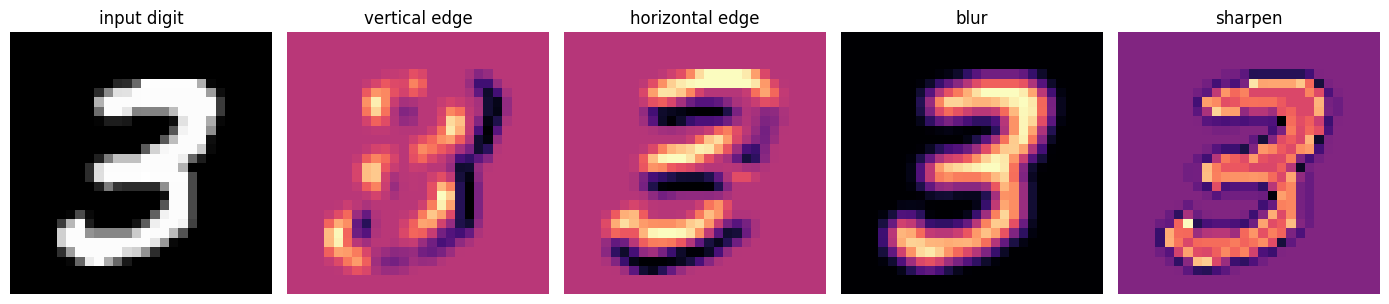

In [2]:
try:
    from torchvision import datasets
    mnist = datasets.MNIST(root="../data", train=True, download=True)
    img = mnist.data[7].numpy().astype(np.float64) / 255.0     # a single digit
    side = 28
except Exception as e:
    print("MNIST unavailable, synthesizing:", repr(e)[:60])
    img = np.zeros((28, 28)); img[6:22, 12:16] = 1.0; img[6:10, 8:20] = 1.0; side = 28

filters = {
    "vertical edge":   np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float),
    "horizontal edge": np.array([[-1,-2,-1],[0,0,0],[1,2,1]], float),
    "blur":            np.ones((3,3))/9,
    "sharpen":         np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], float),
}
x1 = img[None, None]                      # (1,1,28,28)
fig, ax = plt.subplots(1, 5, figsize=(14, 3))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("input digit"); ax[0].axis("off")
for a, (name, k) in zip(ax[1:], filters.items()):
    fmap = conv2d_forward(x1, k[None, None], np.zeros(1), pad=1)[0, 0]
    a.imshow(fmap, cmap="magma"); a.set_title(name); a.axis("off")
plt.tight_layout(); plt.show()


**What to notice.** Each filter is a different question asked at every location: the vertical-edge kernel fires on left/right boundaries, the horizontal-edge kernel on top/bottom boundaries, blur averages, sharpen accentuates. A CNN doesn't *hand-design* these — it **learns** the filter weights by backprop, discovering whichever templates minimize the loss. The key point: one $3\times3$ filter (9 numbers) probes the *entire* image because it's slid across every position. That's weight sharing, and it's why CNNs need so few parameters.


## 2. Pooling — downsampling for invariance

Between convolutions, CNNs **pool**: replace each small window with its max (or average), shrinking the spatial size. Two reasons: it cuts computation, and — more importantly — it grants a little **translation invariance** (if a feature shifts by one pixel, the max over a $2\times2$ window often doesn't change). Max-pool's backward pass routes the gradient only to the position that *was* the max (the "winner"), zeroing the rest — a gradient gate, like ReLU. Here's a from-scratch max-pool, verified against PyTorch.


In [3]:
def maxpool2d_forward(x, K=2, stride=2):
    N, C, H, W = x.shape
    OH, OW = (H-K)//stride+1, (W-K)//stride+1
    out = np.zeros((N, C, OH, OW))
    for i in range(OH):
        for j in range(OW):
            out[:, :, i, j] = x[:, :, i*stride:i*stride+K, j*stride:j*stride+K].max(axis=(2,3))
    return out

x = np.random.randn(2, 3, 8, 8)
ours = maxpool2d_forward(x, 2, 2)
ref  = F.max_pool2d(torch.tensor(x), 2, 2).numpy()
print("our maxpool vs F.max_pool2d, max abs err =", np.abs(ours - ref).max())
assert np.abs(ours - ref).max() < 1e-12
print("✅ from-scratch maxpool matches PyTorch")


our maxpool vs F.max_pool2d, max abs err = 0.0
✅ from-scratch maxpool matches PyTorch


## 3. Train a real CNN (LeNet-style) on MNIST

We've verified the pieces from scratch; now we train a full ConvNet. Pure-NumPy conv training would be painfully slow, so from here we let **PyTorch's autograd + GPU** do the heavy lifting — but note we're still writing the architecture explicitly (`Conv2d → ReLU → MaxPool → … → Linear`), not calling a prebuilt model. This is the LeNet-5 lineage (LeCun, 1998), the network that first made CNNs practical.


In [4]:
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
print("training on", device)

from torchvision import datasets, transforms
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST("../data", train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST("../data", train=False, download=True, transform=tf)
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_ld  = torch.utils.data.DataLoader(test_ds,  batch_size=512)

class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28->14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14->7
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(32*7*7, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.classifier(self.features(x))

cnn = LeNet().to(device)
n_params = sum(p.numel() for p in cnn.parameters())
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
lossf = nn.CrossEntropyLoss()

def evaluate(model):
    model.eval(); correct = 0
    with torch.no_grad():
        for xb, yb in test_ld:
            pred = model(xb.to(device)).argmax(1).cpu()
            correct += (pred == yb).sum().item()
    return correct / len(test_ds)

for epoch in range(3):
    cnn.train()
    for xb, yb in train_ld:
        opt.zero_grad(); loss = lossf(cnn(xb.to(device)), yb.to(device)); loss.backward(); opt.step()
    print(f"epoch {epoch}  test acc {evaluate(cnn):.4f}")
print(f"\nCNN parameters: {n_params:,}")


training on cuda


epoch 0  test acc 0.9775


epoch 1  test acc 0.9849


epoch 2  test acc 0.9882

CNN parameters: 206,922


## 4. The payoff: CNN vs MLP — accuracy *and* parameters

The headline result. Let's put the CNN next to a parameter-matched MLP (like NB6) on the same full MNIST, and compare both **test accuracy** and **parameter count**. Weight sharing should let the CNN win on accuracy *while using far fewer parameters*.


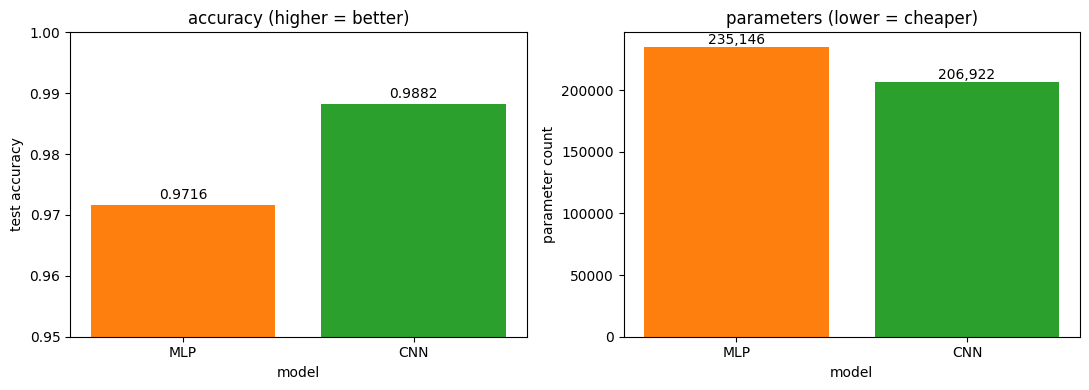

MLP: 0.9716 acc, 235,146 params  |  CNN: 0.9882 acc, 206,922 params


In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(),
                                 nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

mlp = MLP().to(device)
mlp_params = sum(p.numel() for p in mlp.parameters())
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
for epoch in range(3):
    mlp.train()
    for xb, yb in train_ld:
        opt.zero_grad(); lossf(mlp(xb.to(device)), yb.to(device)).backward(); opt.step()
mlp_acc = evaluate(mlp); cnn_acc = evaluate(cnn)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(["MLP", "CNN"], [mlp_acc, cnn_acc], color=["tab:orange", "tab:green"])
ax[0].set_ylim(0.95, 1.0); ax[0].set_ylabel("test accuracy"); ax[0].set_xlabel("model")
ax[0].set_title("accuracy (higher = better)")
for i, v in enumerate([mlp_acc, cnn_acc]): ax[0].text(i, v+0.001, f"{v:.4f}", ha="center")
ax[1].bar(["MLP", "CNN"], [mlp_params, n_params], color=["tab:orange", "tab:green"])
ax[1].set_ylabel("parameter count"); ax[1].set_xlabel("model"); ax[1].set_title("parameters (lower = cheaper)")
for i, v in enumerate([mlp_params, n_params]): ax[1].text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"MLP: {mlp_acc:.4f} acc, {mlp_params:,} params  |  CNN: {cnn_acc:.4f} acc, {n_params:,} params")


**What to notice.** The CNN reaches **higher accuracy with fewer parameters**. That's not a free lunch from having "more layers" — it's the *inductive bias* paying off: by hard-coding locality and weight-sharing into the architecture, the CNN doesn't waste capacity re-learning the same edge detector at every one of 784 positions. It matches the structure of the data (images have local, translation-invariant features), so it generalizes better per parameter. Choosing an architecture whose built-in assumptions match your data is one of the highest-leverage decisions in deep learning — and it's exactly why transformers (whose bias suits *sequences*) later took over language.


## 5. What the CNN learned — filters and feature maps

Because conv filters are small images, we can *look* at them. Below: the 16 learned first-layer filters, and the feature maps they produce on a real test digit (each map = "where in this digit does filter $k$'s pattern occur").


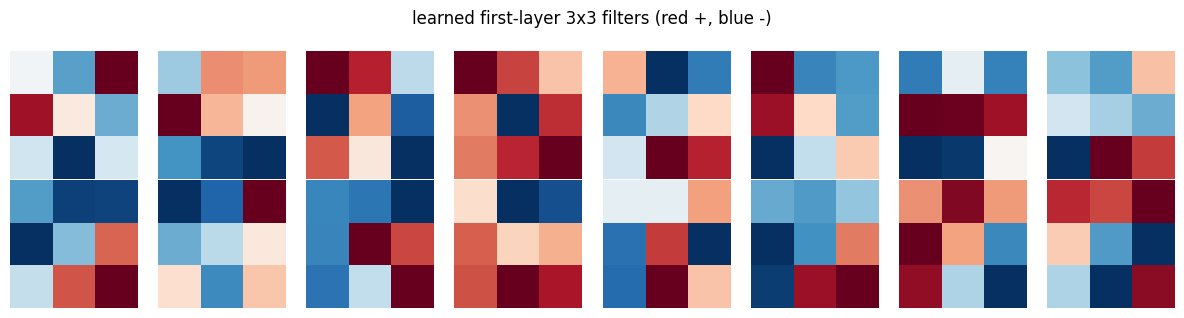

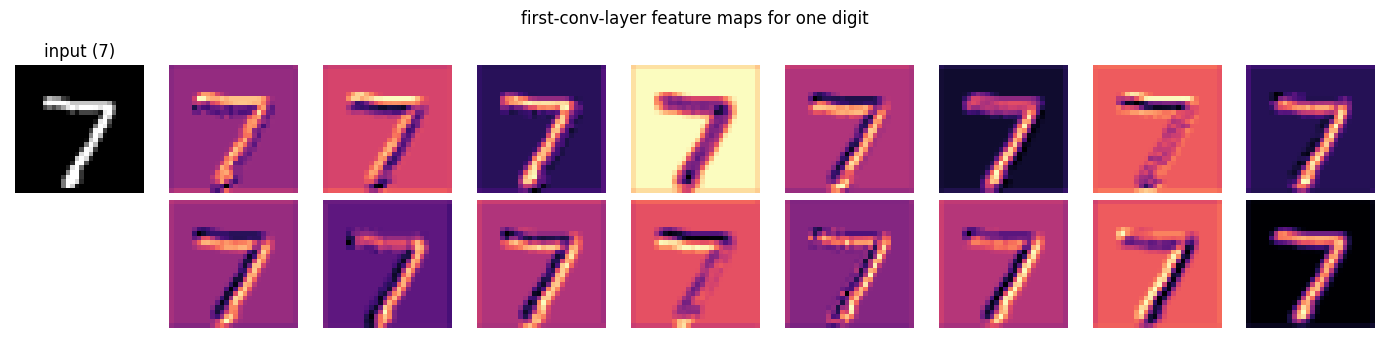

In [6]:
W1 = cnn.features[0].weight.data.cpu().numpy()   # (16,1,3,3)
fig, ax = plt.subplots(2, 8, figsize=(12, 3.2))
for k, a in enumerate(ax.ravel()):
    a.imshow(W1[k, 0], cmap="RdBu"); a.axis("off")
fig.suptitle("learned first-layer 3x3 filters (red +, blue -)"); plt.tight_layout(); plt.show()

# feature maps on one test digit
ex, lbl = test_ds[0]
with torch.no_grad():
    fmaps = cnn.features[0](ex[None].to(device)).cpu().numpy()[0]   # (16,28,28)
fig, ax = plt.subplots(2, 9, figsize=(14, 3.4))
ax[0,0].imshow(ex[0], cmap="gray"); ax[0,0].set_title(f"input ({lbl})"); ax[0,0].axis("off")
ax[1,0].axis("off")
for k in range(16):
    a = ax[k//8, 1+k%8]; a.imshow(fmaps[k], cmap="magma"); a.axis("off")
fig.suptitle("first-conv-layer feature maps for one digit"); plt.tight_layout(); plt.show()


**What to notice.** The learned filters (top) aren't random — many resemble oriented edge/stroke detectors, echoing the hand-designed Sobel kernels from §1, but *discovered* by gradient descent. The feature maps show each filter activating on the specific strokes of the digit it responds to. Stack more conv layers and later filters combine these edges into corners, then loops, then whole digit-parts — the classic hierarchy of features. You are literally seeing "what the network sees."


## 6. Translation equivariance, demonstrated

The defining property: **shift the input, and the feature maps shift with it** (equivariance), because the same filter slides everywhere. This is what weight-sharing buys, and why a CNN recognizes a digit whether it's centered or off to one side.


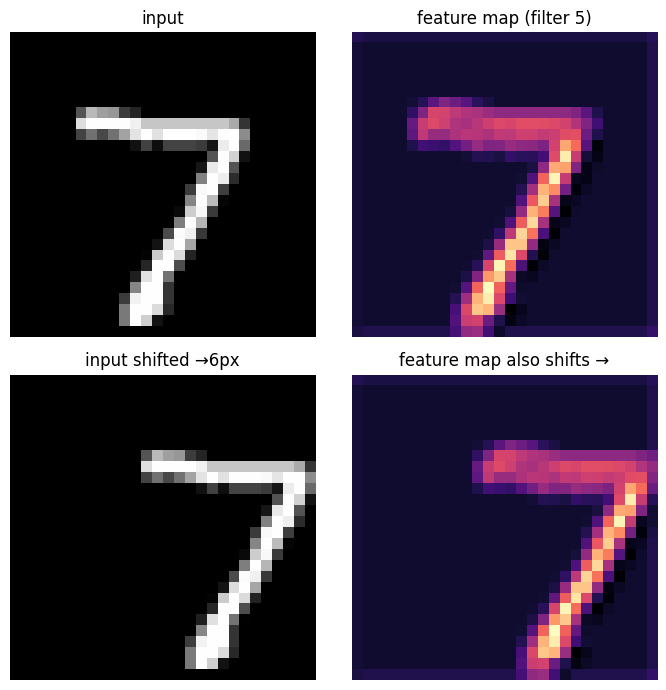

In [7]:
digit = test_ds[0][0]                                  # (1,28,28)
shifted = torch.roll(digit, shifts=6, dims=2)         # shift right by 6 px
with torch.no_grad():
    f0 = cnn.features[0](digit[None].to(device)).cpu()[0, 5]
    f1 = cnn.features[0](shifted[None].to(device)).cpu()[0, 5]
fig, ax = plt.subplots(2, 2, figsize=(7, 7))
ax[0,0].imshow(digit[0], cmap="gray"); ax[0,0].set_title("input"); ax[0,0].axis("off")
ax[0,1].imshow(f0, cmap="magma"); ax[0,1].set_title("feature map (filter 5)"); ax[0,1].axis("off")
ax[1,0].imshow(shifted[0], cmap="gray"); ax[1,0].set_title("input shifted →6px"); ax[1,0].axis("off")
ax[1,1].imshow(f1, cmap="magma"); ax[1,1].set_title("feature map also shifts →"); ax[1,1].axis("off")
plt.tight_layout(); plt.show()


**What to notice.** The bottom feature map is the top one *translated* — the response pattern moved exactly with the input. A CNN doesn't have to learn the digit at every position separately; a feature detected anywhere produces the same activation, just relocated. Pooling then adds a bit of *invariance* on top (small shifts get absorbed). Equivariance (conv) + invariance (pool) is the recipe that makes CNNs robust to where an object appears.

## 7. What you built / learned
- Verified our from-scratch **im2col conv** and **max-pool** against PyTorch.
- Saw convolution as **feature extraction** (filters = learnable templates, feature maps = where they match).
- Trained a **LeNet** to ~99% and showed a CNN beats an MLP on **both accuracy and parameter count** — the power of a matched inductive bias (locality + weight sharing).
- Visualized **learned filters, feature maps**, and **translation equivariance**.

## 8. Exercises
1. **Deeper/receptive field.** Add a third conv block. How does test accuracy and the *receptive field* (how much of the input one deep neuron sees) change?
2. **1×1 convolutions.** What does a $1\times1$ conv do? (Hint: it's a per-pixel MLP across channels.) Add one and see.
3. **Global average pooling.** Replace the flatten+Linear head with global average pooling over the feature maps. Fewer params — does accuracy hold?
4. **CIFAR-10.** Swap MNIST for CIFAR-10 (3-channel, harder). What accuracy does LeNet reach, and why is it much lower than on MNIST?
5. **Strided conv vs pooling.** Replace `MaxPool2d(2)` with a stride-2 conv. Compare params and accuracy — this is what modern nets often do.
6. **Filter count sweep.** Vary the first layer's filter count (4, 16, 64). Plot accuracy vs params — where are the diminishing returns?

## 9. Interview / residency framing
- *"Why CNNs over MLPs for images?"* → locality + weight sharing → far fewer params, translation equivariance, an inductive bias matched to image structure.
- *"What is weight sharing and why does it help?"* → the same filter is applied at every position, so a feature is learned once and detected everywhere; drastically fewer parameters, better generalization.
- *"Equivariance vs invariance?"* → conv is equivariant (shift in → shift out); pooling adds invariance (small shifts absorbed).
- *"How is conv computed efficiently?"* → im2col turns it into a matmul (BLAS/GPU); this notebook's `Conv2d`.
- *"What do early vs late filters learn?"* → early: edges/strokes; later: corners, textures, object parts — a feature hierarchy.

---
**Next:** *Tier 1 · Notebook 8 — RNNs & LSTMs from scratch*: sequence modeling, backprop-through-time by hand, the vanishing-gradient problem visualized, and a char-level language model — the on-ramp to attention and transformers.


## 📚 References & papers

This notebook reproduces / builds on:

- **Gradient-Based Learning Applied to Document Recognition (LeNet-5)** — LeCun et al. (1998).
- **ImageNet Classification with Deep CNNs (AlexNet)** — Krizhevsky, Sutskever & Hinton (2012), NeurIPS.
- **Deep Residual Learning (ResNet)** — He et al. (2015), arXiv:1512.03385.